# Steam review playerbase over time: Apex Legends & PUBG

**Purpose:** `collectors/steam_review_history_pull.py`'s first real
crawls (completed 2026-09-13) give this project its first look at a
title's *playerbase* over time, as distinct from its Twitch
*viewership* -- owners who bothered to write a review, not streamers or
the people watching them. Generalizes `notebooks/
pubg_playerbase_over_time.ipynb`'s PUBG-only analysis to run both
crawled subjects side by side, superseding that notebook.

**Steam reviews are not a random sample, in either dimension -- checked
directly, not assumed (2026-09-13):**
- **Time**: `filter=recent`'s cursor pagination has a real,
  community-documented Steam bug (the cursor eventually starts
  repeating one it already handed out) that stops each crawl at a hard
  wall, not a sample spread across a title's whole history. Confirmed
  the reached window itself has **zero gap days** for both subjects --
  a complete census of that period, then nothing before it:
  - **PUBG: BATTLEGROUNDS**: 536,953 of 2,753,749 total reviews (19.5%),
    2023-12-25 to 2026-09-13 (994/994 days present).
  - **Apex Legends**: 591,924 of 1,068,719 total reviews (55.4%),
    2022-09-25 to 2026-09-13 (1,450/1,450 days present).
  - Neither reaches each title's actual release (PUBG 2017-12-21, Apex
    2019-02-04). **Correction, 2026-09-13**: an earlier version of this
    note claimed the two crawls stopped at a similar absolute PAGE
    count, suggesting a fixed platform-side pagination-depth ceiling --
    a third crawl (Counter-Strike 2, run afterward) contradicts that:
    it reached 1,100,240 reviews over ~11,000 pages, roughly double
    either of these two, covering only 2025-07-14 onward (~14 months,
    the shortest window of the three despite the most pages and most
    reviews). So the depth this endpoint can reach is real and hits
    every high-volume title, but it is NOT a fixed constant across
    titles -- more likely dependent on each title's own review-posting
    velocity and pattern in a way not yet characterized. Treat the
    specific cutoff point as title-specific and empirical (check
    `MIN(timestamp_created)` per subject), not predictable in advance.
- **Population**: reviewers are self-selected, not a random draw from
  the playerbase. More-engaged players review more; sentiment is
  bimodal; Steam's own review-prompt UI and regional review-writing
  norms can skew who shows up. Full detail in `analysis/
  fandom_region_decomposition.py`'s module docstring. Read everything
  below as "who chose to review, day by day, within each title's own
  reached window" -- never as a random sample of who plays either game.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etl.db import get_connection
from analysis.fandom_region_decomposition import (
    CANDIDATE_ENGLISH_COUNTRIES,
    CANDIDATE_GLOBAL_COUNTRIES,
    calibrate_timezone_curve,
    decompose_by_timezone,
    get_steam_review_hourly_series,
    load_subjects,
)

SUBJECT_IDS = ["apex_legends", "pubg"]
subjects = load_subjects()
conn = get_connection()
calibration_curve = calibrate_timezone_curve(conn)

reviews_by_subject = {}
for sid in SUBJECT_IDS:
    rows = conn.execute(
        "SELECT timestamp_created, language FROM steam_review_history WHERE subject_id = ?", (sid,)
    ).fetchall()
    df = pd.DataFrame(rows, columns=["timestamp_created", "language"])
    df["dt"] = pd.to_datetime(df["timestamp_created"], unit="s", utc=True)
    df["month"] = df["dt"].dt.to_period("M")
    df["quarter"] = df["dt"].dt.to_period("Q")
    reviews_by_subject[sid] = df
    print(f"{subjects[sid]['display_name']}: {len(df)} reviews, {df['dt'].min()} to {df['dt'].max()}")

/tmp/ipykernel_54705/2698628409.py:39: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["dt"].dt.to_period("M")
/tmp/ipykernel_54705/2698628409.py:40: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["quarter"] = df["dt"].dt.to_period("Q")


Apex Legends: 591924 reviews, 2022-09-25 21:26:11+00:00 to 2026-09-13 07:46:33+00:00


PUBG: BATTLEGROUNDS: 536953 reviews, 2023-12-25 15:01:03+00:00 to 2026-09-13 08:07:31+00:00


/tmp/ipykernel_54705/2698628409.py:39: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["dt"].dt.to_period("M")
/tmp/ipykernel_54705/2698628409.py:40: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["quarter"] = df["dt"].dt.to_period("Q")


## Review volume over time

Both on one chart for comparison -- note the windows differ (PUBG's is
shorter, starting later). **Caveat before reading this as a
playerbase-size proxy**: review volume is also a function of Steam's own
review-prompt UI, sale/free-weekend spikes, and major-update cycles.

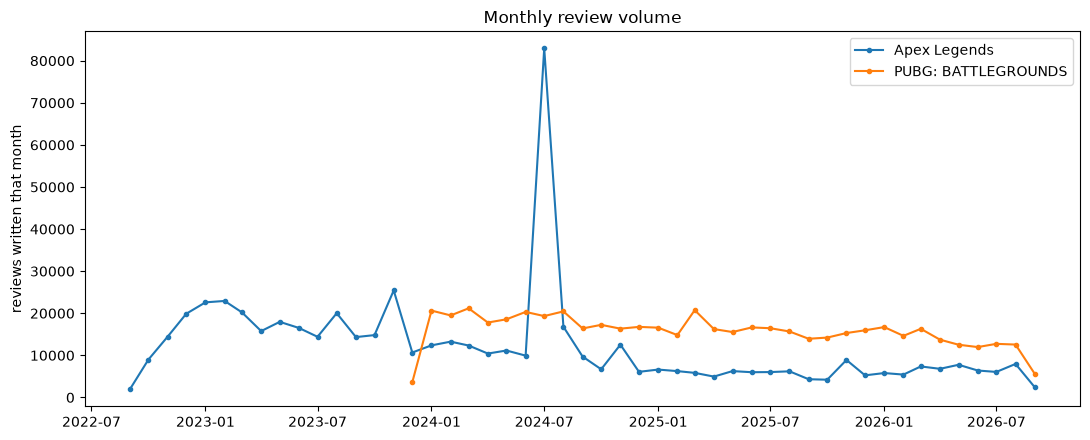

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for sid in SUBJECT_IDS:
    monthly = reviews_by_subject[sid].groupby("month").size()
    ax.plot(monthly.index.to_timestamp(), monthly.values, marker="o", markersize=3, label=subjects[sid]["display_name"])
ax.set_ylabel("reviews written that month")
ax.set_title("Monthly review volume")
ax.legend()
plt.tight_layout()
plt.show()

## Language mix over time

Top 6 languages per subject (they differ), "other" collapsing the rest --
normalized to a monthly SHARE so a change in total volume isn't mistaken
for a change in composition.

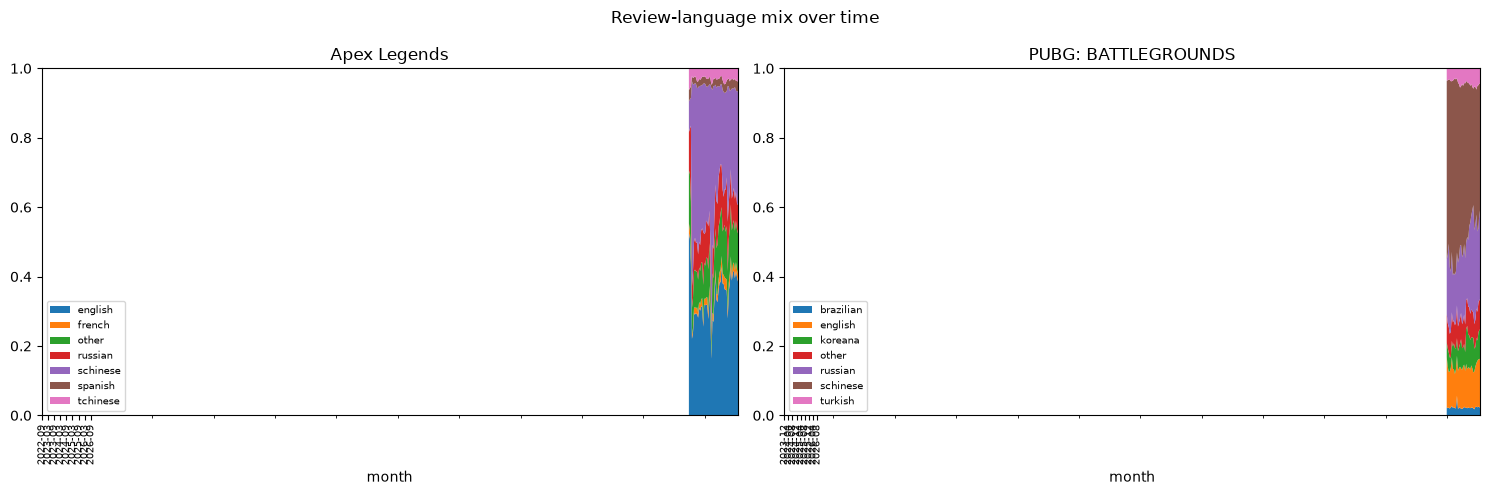

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, sid in zip(axes, SUBJECT_IDS):
    df = reviews_by_subject[sid]
    top_languages = df["language"].value_counts().head(6).index.tolist()
    df = df.copy()
    df["lang_bucket"] = df["language"].where(df["language"].isin(top_languages), "other")
    monthly_lang = df.groupby(["month", "lang_bucket"]).size().unstack(fill_value=0)
    monthly_lang_share = monthly_lang.div(monthly_lang.sum(axis=1), axis=0)
    monthly_lang_share.plot(kind="area", stacked=True, ax=ax, linewidth=0, legend=True)
    ax.set_title(subjects[sid]["display_name"])
    ax.set_ylim(0, 1)
    ax.set_xticks(range(0, len(monthly_lang_share.index), max(1, len(monthly_lang_share.index)//8)))
    ax.set_xticklabels([str(monthly_lang_share.index[i]) for i in ax.get_xticks()], rotation=90, fontsize=7)
    ax.legend(fontsize=7, loc="lower left")
plt.suptitle("Review-language mix over time")
plt.tight_layout()
plt.show()

## English-speaking regional decomposition, over time

Same `decompose_by_timezone` method as `notebooks/
english_fandom_decomposition.ipynb`, applied per quarter -- possible here
because `steam_review_history` spans multiple years per subject, unlike
Twitch's ~2-week `language_mix_snapshots` coverage. Quarters with fewer
than 30 English reviews are dropped, not shown as zero.

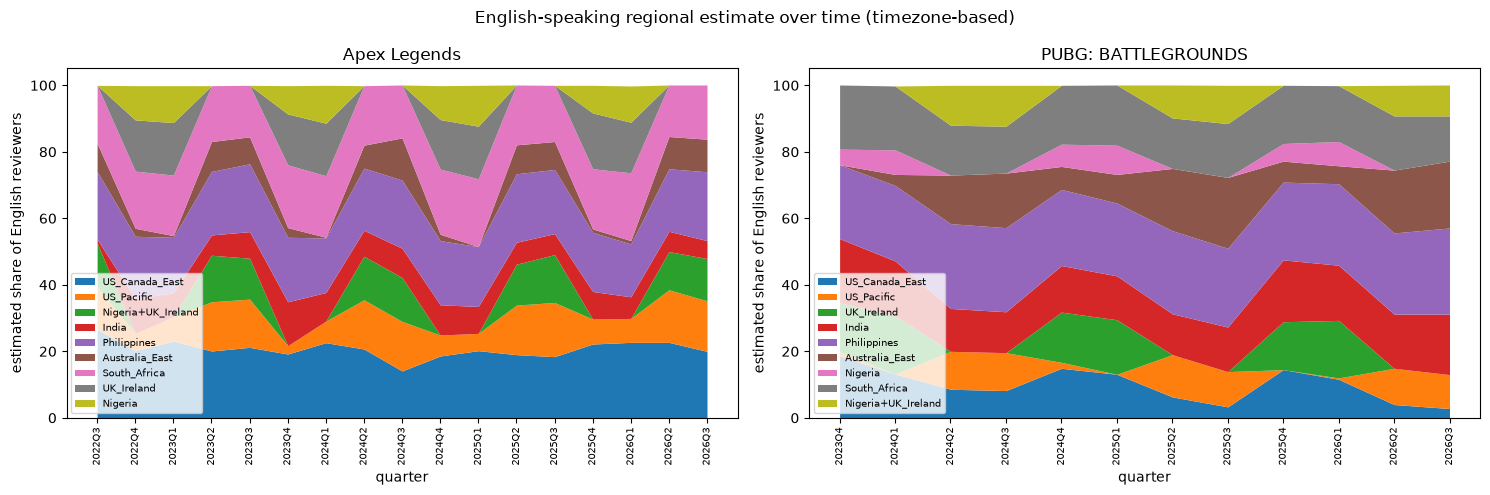

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
english_region_by_subject = {}
for ax, sid in zip(axes, SUBJECT_IDS):
    subject = subjects[sid]
    quarters = sorted(reviews_by_subject[sid]["quarter"].unique())
    rows = []
    for q in quarters:
        since_dt = q.start_time.tz_localize("UTC")
        until_dt = q.end_time.tz_localize("UTC")
        hourly = get_steam_review_hourly_series(conn, subject, language="english", since=int(since_dt.timestamp()), until=int(until_dt.timestamp()))
        if hourly.sum() < 30:
            continue
        reference_datetime = (since_dt + (until_dt - since_dt) / 2).to_pydatetime()
        shares = decompose_by_timezone(hourly, CANDIDATE_ENGLISH_COUNTRIES, calibration_curve=calibration_curve, reference_datetime=reference_datetime)
        rows.append({"quarter": str(q), "english_reviews": int(hourly.sum()), **{k: round(v * 100, 1) for k, v in shares.items()}})
    df = pd.DataFrame(rows).set_index("quarter")
    english_region_by_subject[sid] = df
    df.drop(columns="english_reviews").fillna(0).plot(kind="area", stacked=True, ax=ax, linewidth=0, legend=True)
    ax.set_title(subject["display_name"])
    ax.set_ylabel("estimated share of English reviewers")
    ax.set_xticks(range(len(df.index)))
    ax.set_xticklabels(df.index, rotation=90, fontsize=7)
    ax.legend(fontsize=7, loc="lower left")
plt.suptitle("English-speaking regional estimate over time (timezone-based)")
plt.tight_layout()
plt.show()

## Whole-playerbase regional decomposition, over time

Pooled across ALL languages (`language=None`), against
`CANDIDATE_GLOBAL_COUNTRIES` -- built from these two titles' own actual
top review languages (China, Japan/South Korea, Russia/Turkey, Brazil,
Western Europe, North America), collision-checked the same way as
`CANDIDATE_ENGLISH_COUNTRIES` (see that constant's module comment for
why this collision keeps recurring).

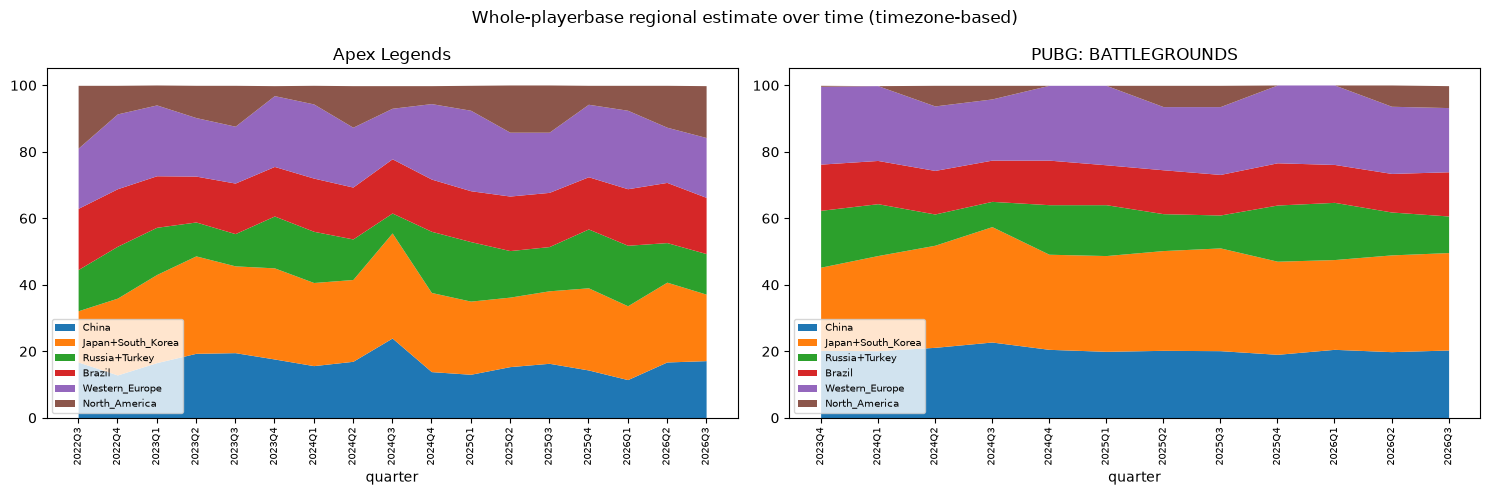

--- Apex Legends ---


,total_reviews,China,Japan+South_Korea,Russia+Turkey,Brazil,Western_Europe,North_America
quarter,,,,,,,
2022Q3,1924,16.8,15.4,12.4,18.4,18.1,18.9
2022Q4,43317,12.9,23.1,15.6,17.3,22.5,8.6
2023Q1,65724,16.6,26.5,14.2,15.5,21.3,6.0
2023Q2,50233,19.4,29.3,10.2,13.8,17.6,9.7
2023Q3,48765,19.6,26.1,9.7,15.2,17.1,12.3
2023Q4,50914,17.7,27.4,15.6,14.9,21.3,3.0
2024Q1,37960,15.7,25.0,15.4,16.0,22.3,5.6
2024Q2,31508,17.0,24.6,12.2,15.6,18.0,12.5
2024Q3,109432,24.0,31.6,6.0,16.3,15.2,6.8


--- PUBG: BATTLEGROUNDS ---


,total_reviews,China,Japan+South_Korea,Russia+Turkey,Brazil,Western_Europe,North_America
quarter,,,,,,,
2023Q4,3616,20.3,25.0,17.1,13.9,23.4,0.3
2024Q1,61294,20.2,28.6,15.6,13.0,22.5,0.0
2024Q2,56675,21.2,30.7,9.4,13.1,19.4,6.2
2024Q3,56168,22.8,34.7,7.6,12.4,18.4,4.1
2024Q4,50353,20.6,28.6,14.9,13.4,22.5,0.0
2025Q1,52128,20.0,28.8,15.3,12.0,23.9,0.0
2025Q2,48413,20.3,30.0,11.1,13.2,19.0,6.4
2025Q3,46056,20.2,30.9,9.9,12.2,20.4,6.4
2025Q4,45475,19.1,28.0,16.9,12.7,23.4,0.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
pooled_by_subject = {}
for ax, sid in zip(axes, SUBJECT_IDS):
    subject = subjects[sid]
    quarters = sorted(reviews_by_subject[sid]["quarter"].unique())
    rows = []
    for q in quarters:
        since_dt = q.start_time.tz_localize("UTC")
        until_dt = q.end_time.tz_localize("UTC")
        hourly = get_steam_review_hourly_series(conn, subject, language=None, since=int(since_dt.timestamp()), until=int(until_dt.timestamp()))
        if hourly.sum() < 30:
            continue
        reference_datetime = (since_dt + (until_dt - since_dt) / 2).to_pydatetime()
        shares = decompose_by_timezone(hourly, CANDIDATE_GLOBAL_COUNTRIES, calibration_curve=calibration_curve, reference_datetime=reference_datetime)
        rows.append({"quarter": str(q), "total_reviews": int(hourly.sum()), **{k: round(v * 100, 1) for k, v in shares.items()}})
    df = pd.DataFrame(rows).set_index("quarter")
    pooled_by_subject[sid] = df
    df.drop(columns="total_reviews").fillna(0).plot(kind="area", stacked=True, ax=ax, linewidth=0, legend=True)
    ax.set_title(subject["display_name"])
    ax.set_xticks(range(len(df.index)))
    ax.set_xticklabels(df.index, rotation=90, fontsize=7)
    ax.legend(fontsize=7, loc="lower left")
plt.suptitle("Whole-playerbase regional estimate over time (timezone-based)")
plt.tight_layout()
plt.show()

for sid in SUBJECT_IDS:
    print(f"--- {subjects[sid]['display_name']} ---")
    display(pooled_by_subject[sid])

## Caveats -- read everything above as directional, not settled

- **Neither subject's window reaches its actual release** -- PUBG covers
  late 2023 onward (not since 2017), Apex covers late 2022 onward (not
  since 2019). Any claim about either title's launch-era or mid-life
  playerbase cannot be answered from this data.
- **Steam reviews are not a random sample, in either dimension** -- see
  this notebook's opening section and `analysis/
  fandom_region_decomposition.py`'s module docstring for the full
  detail (verified zero gap days within each window; self-selected
  reviewer population).
- **Review volume is not a clean playerbase-size proxy** -- a given
  month's spike could be a sale, a major update, or a review-prompt
  campaign as easily as organic growth.
- **DST is handled properly as of 2026-09-14** -- each quarter's
  decomposition uses that quarter's own midpoint to resolve real,
  DST-aware offsets (`analysis/fandom_region_decomposition.py`'s module
  docstring), not a single fixed-offset table. Practical consequence
  visible in the charts above: **a candidate's column can appear under a
  different name, or merged with a different neighbor, from one quarter
  to the next** (e.g. `Japan+South_Korea` always merges, since neither
  observes DST, but an English-set candidate involving UK/Nigeria could
  in principle split or merge quarter to quarter) -- that's the model
  correctly reporting which regions are identifiable in each specific
  season, not a bug or inconsistent labeling. `CANDIDATE_GLOBAL_COUNTRIES`
  itself is still a judgment call built from these two titles' own top
  languages, not a general-purpose list for any title.
- **Some region pairs are structurally indistinguishable by clock time
  alone, for part or all of the year, no matter how the offsets are
  tuned** -- South Africa (no DST, fixed UTC+2) and Central Europe (CEST,
  UTC+2 in summer) is the clearest example, confirmed directly 2026-09-14.
  Timezone deconvolution auto-merges such pairs when both are candidates;
  when only one is (as here), the merged-away one's real activity has
  nowhere else to go except silently blending into whichever candidate
  currently shares its clock. A different signal (language, self-declared
  tags) is needed to actually separate them.
- **Language and country/region are not the same claim** -- a `schinese`
  reviewer is very likely but not certainly in mainland China; same
  caveat this subsystem carries everywhere it uses language as a region
  proxy.